In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import time

# ==================== 1. 设备设置 ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前设备: {device}")

# ==================== 2. 数据加载（复用任务A） ====================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_dir = './data/PlantVillage'
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"类别: {class_names}")
print(f"类别数: {num_classes}")

当前设备: cuda
类别: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
类别数: 4


In [2]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = test_transform

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集: {train_size} 张")
print(f"验证集: {val_size} 张")

训练集: 5300 张
验证集: 1325 张


In [3]:
def train_model(model, optimizer, epochs=5, name=""):
    """通用训练函数"""
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_accs = []
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        # 验证阶段
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        
        avg_loss = running_loss / len(train_loader)
        val_acc = 100.0 * correct / total
        train_losses.append(avg_loss)
        val_accs.append(val_acc)
        
        print(f"{name} Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    return train_losses, val_accs

In [4]:
# 模型1: ResNet18
print("\n=== 加载 ResNet18 ===")
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 冻结所有参数
for param in model_resnet.parameters():
    param.requires_grad = False

# 替换分类头
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)
model_resnet = model_resnet.to(device)

# 统计参数
resnet_params = sum(p.numel() for p in model_resnet.parameters())
resnet_trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"ResNet18 总参数: {resnet_params:,}")
print(f"ResNet18 可训练参数: {resnet_trainable:,}")

# 模型2: MobileNetV2
print("\n=== 加载 MobileNetV2 ===")
model_mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# 冻结所有参数
for param in model_mobilenet.parameters():
    param.requires_grad = False

# 替换分类头（注意MobileNetV2的结构）
# MobileNetV2 使用 classifier 作为分类头，它是一个 Sequential 容器
# classifier[1] 是最后的 Linear 层
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.classifier[1].in_features, num_classes)
model_mobilenet = model_mobilenet.to(device)

# 统计参数
mobile_params = sum(p.numel() for p in model_mobilenet.parameters())
mobile_trainable = sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad)
print(f"MobileNetV2 总参数: {mobile_params:,}")
print(f"MobileNetV2 可训练参数: {mobile_trainable:,}")



=== 加载 ResNet18 ===
ResNet18 总参数: 11,178,564
ResNet18 可训练参数: 2,052

=== 加载 MobileNetV2 ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100.0%


MobileNetV2 总参数: 2,228,996
MobileNetV2 可训练参数: 5,124


In [5]:
epochs = 5

# 训练 ResNet18
print("\n" + "="*50)
print("开始训练 ResNet18")
print("="*50)
optimizer_resnet = optim.Adam(model_resnet.fc.parameters(), lr=0.001)
resnet_losses, resnet_accs = train_model(model_resnet, optimizer_resnet, epochs, name="ResNet18")

# 训练 MobileNetV2
print("\n" + "="*50)
print("开始训练 MobileNetV2")
print("="*50)
optimizer_mobile = optim.Adam(model_mobilenet.classifier[1].parameters(), lr=0.001)
mobile_losses, mobile_accs = train_model(model_mobilenet, optimizer_mobile, epochs, name="MobileNetV2")


开始训练 ResNet18
ResNet18 Epoch [1/5] | Loss: 0.5689 | Val Acc: 89.74%
ResNet18 Epoch [2/5] | Loss: 0.2709 | Val Acc: 94.04%
ResNet18 Epoch [3/5] | Loss: 0.2200 | Val Acc: 93.96%
ResNet18 Epoch [4/5] | Loss: 0.1827 | Val Acc: 94.94%
ResNet18 Epoch [5/5] | Loss: 0.1665 | Val Acc: 94.87%

开始训练 MobileNetV2
MobileNetV2 Epoch [1/5] | Loss: 0.5921 | Val Acc: 92.53%
MobileNetV2 Epoch [2/5] | Loss: 0.2941 | Val Acc: 95.55%
MobileNetV2 Epoch [3/5] | Loss: 0.2234 | Val Acc: 96.00%
MobileNetV2 Epoch [4/5] | Loss: 0.1899 | Val Acc: 96.83%
MobileNetV2 Epoch [5/5] | Loss: 0.1684 | Val Acc: 96.98%


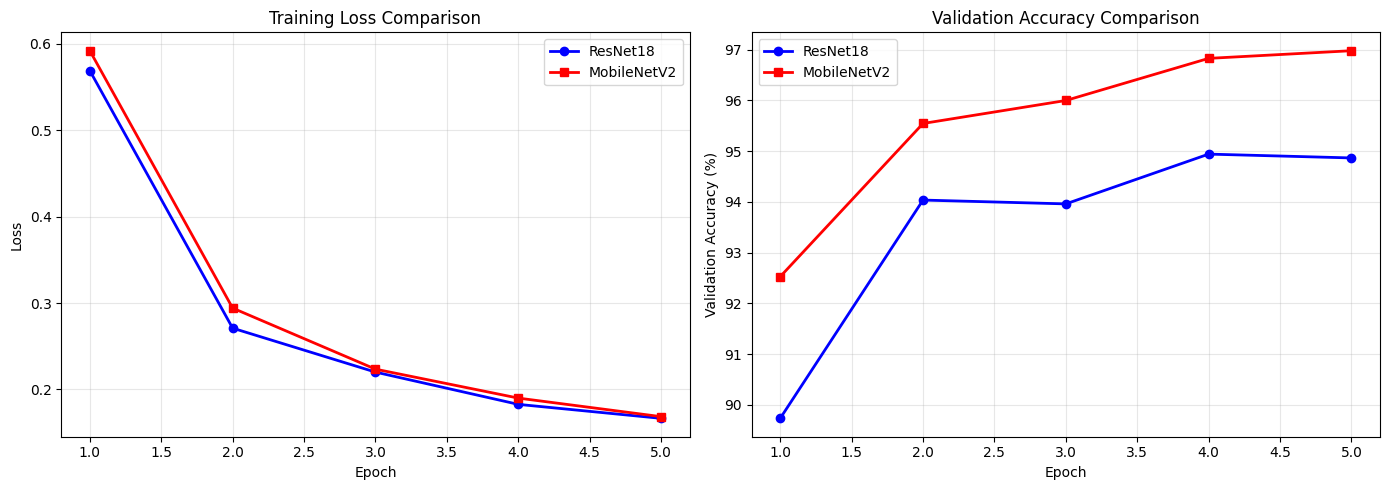

In [6]:
 fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线对比
ax1.plot(range(1, epochs+1), resnet_losses, 'bo-', label='ResNet18', linewidth=2)
ax1.plot(range(1, epochs+1), mobile_losses, 'rs-', label='MobileNetV2', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 准确率曲线对比
ax2.plot(range(1, epochs+1), resnet_accs, 'bo-', label='ResNet18', linewidth=2)
ax2.plot(range(1, epochs+1), mobile_accs, 'rs-', label='MobileNetV2', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task_c_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
print("\n" + "="*50)
print("最终结果对比")
print("="*50)
print(f"ResNet18 最佳准确率: {max(resnet_accs):.2f}%")
print(f"MobileNetV2 最佳准确率: {max(mobile_accs):.2f}%")
print(f"参数对比: ResNet18 ({resnet_params:,}) vs MobileNetV2 ({mobile_params:,})")
print(f"参数量比例: MobileNetV2 是 ResNet18 的 {mobile_params/resnet_params*100:.1f}%")


最终结果对比
ResNet18 最佳准确率: 94.94%
MobileNetV2 最佳准确率: 96.98%
参数对比: ResNet18 (11,178,564) vs MobileNetV2 (2,228,996)
参数量比例: MobileNetV2 是 ResNet18 的 19.9%
